In [22]:
from pathlib import Path

import numpy             as np
import pandas            as pd
import tables            as tb
import scipy.stats       as st
import matplotlib.pyplot as plt
import tomllib

from nbtools import auto_plot_style
from jupyfun import progressbar
from jupyfun import in_range

In [23]:
#%matplotlib inline
auto_plot_style()

In [33]:
path  = Path("../data/test/")
sipms = pd.read_csv(path / "images.csv"         , sep=" ", header=0)
fine  = pd.read_csv(path / "detailed_images.csv", sep=" ", header=None).values
conf  = tomllib.loads(open(path / "run.conf").read())

size   = conf["geometry"]["sipm_plane"]["sipm_size"]
gap    = conf["geometry"]["sipm_plane"]["sipm_gap"]
nsipms = conf["geometry"]["sipm_plane"]["n_sipms_side"]
pitch  = size + gap
extent = nsipms * pitch / 2.
extent = (-extent, extent)*2

xyfine = np.linspace(*extent[:2], 101)[:-1]
xfine, yfine = np.meshgrid(xyfine, xyfine, indexing="ij")

sipmbins = []
for i in range(nsipms):
    sipmbins.append(extent[0] + i*pitch)
    sipmbins.append(extent[0] + i*pitch + gap/2)
    sipmbins.append(extent[0] + i*pitch + gap/2 + size)
sipmbins.append(extent[-1])

[  0.   0.   0.   0.   0.   0.   0.   0.   0. 376.   0.   0.   0.   0.]
15.138480646870333 -3.5813968928802757
1587 1813


IndexError: single positional indexer is out-of-bounds

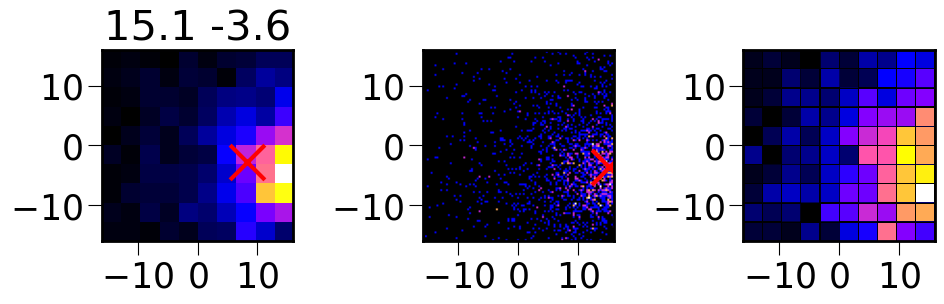

<Figure size 1000x800 with 0 Axes>

In [34]:
for i in range(10):
    plt.figure()
    
    x, y = sipms.iloc[i, 1:3]
    qs   = sipms.iloc[i, 3:3+14].values
    print(qs)
    img  = sipms.iloc[i:i+1].filter(regex="img_*").values
    n    = int(img.size**0.5)
    img  = img.reshape(n, n)

    xb = np.sum(img.sum(axis=0) * (np.arange(n)+0.5) * pitch) / img.sum() + extent[0]
    yb = np.sum(img.sum(axis=1) * (np.arange(n)+0.5) * pitch) / img.sum() + extent[0]

    img2 = fine[i]
    n    = int(img2.size**0.5)
    img2 = img2.reshape(n, n)

    print(x, y)
    print(img.sum(), img2.sum())
    xi, yi = map(np.ravel, (img2.T*xfine, img2.T*yfine))
    plt.subplot(1, 3, 1)
    plt.imshow(img, origin="lower", extent=extent)
    plt.scatter([xb], [yb], marker="x", color="r")
    plt.title(f"{x:.1f} {y:.1f}")

    plt.subplot(1, 3, 2)
    plt.imshow(img2, origin="lower", extent=extent)
    plt.scatter([x], [y], marker="x", color="r")

    plt.subplot(1, 3, 3)
    plt.hist2d(xi, yi, (sipmbins,)*2, cmin=0, cmax=img.max())
    plt.gca().set_aspect(1)
    plt.tight_layout()

In [35]:
img

array([[  2,   2,   1,   5,   3,   9,  10,  31,  21,  11],
       [  3,   2,   7,   4,  13,  11,  19,  27,  42,  48],
       [  1,   5,   6,   6,   8,  14,  24,  36,  84,  96],
       [  1,   2,   7,   7,   8,  11,  21,  40,  67, 104],
       [  4,   1,   8,   3,   6,   7,  27,  51,  64,  95],
       [  0,   3,   6,   3,   9,  16,  23,  30,  46,  54],
       [  2,   0,   4,   7,   5,  10,  18,  23,  17,  34],
       [  1,   2,   5,   5,   4,   9,  13,  14,  12,  24],
       [  2,   3,   5,   2,   6,   5,   1,  10,  16,  13],
       [  1,   2,   1,   0,   5,   2,   5,   6,   9,   9]])